## SPC4003: Coding practices in AI development

## Final project

### This assignment is worth 50% of total marks for the module.

* Deadline: Friday 15th May, 2026
* Coding can be done in any environmment of your choice
* The project consists in filling in the Jupyter Notebook, resulting in a running Notebook.
* Some cells contain question that need to be answered in markdown (text)
* This Jupyter Notebook and associated dataset can be downloaded from QMPlus.
* The project will need to be uploaded as a Jupyter Notebook, renamed with your last name
* Standard late penalties (5% of total assignment mark per day, for a maximum of 5 days).
* Late assignments will not be considered after May 20th, 2026.

## Use the NASA OMNI2 dataset to develop a forecasting model for the Dst index

The solar wind is a continuous stream of charged particles (mostly electrons and protons) flowing outward from the Sun's corona into space. This phenomenon occurs at varying speeds, typically ranging from 300 to 800 kilometers per second, and carries with it the Sun's magnetic field.

The solar wind plays a significant role in the dynamics of our solar system, impacting planetary atmospheres, magnetospheres, and even influencing space weather phenomena. It can interact with Earth's magnetic field, causing phenomena like geomagnetic storms, auroras, and disruptions in satellite communications and power grids.

NASA's OMNI dataset is a collection of near-Earth solar wind and magnetic field data, among other parameters, gathered from multiple spacecraft missions. These data provide valuable insights into the behaviour of the solar wind and its interaction with Earth's magnetosphere. Researchers and scientists use the OMNI dataset for various studies related to space weather, magnetospheric physics, and solar-terrestrial interactions. It serves as a crucial resource for understanding and predicting space weather events and their potential impacts on technological systems and human activities in space and on Earth.

The Geomagnetic Dst index, or Disturbance Storm-Time index, is a measure of the strength of geomagnetic storms. It is derived from measurements of the horizontal component of the Earth's magnetic field at mid-latitude magnetometer stations. The Dst index provides a quantitative measure of how much the Earth's magnetic field is disturbed during geomagnetic storms, with negative values indicating magnetic storms and positive values indicating quieter conditions. It is commonly used by researchers and space weather forecasters to monitor and assess the impact of solar activity on Earth's magnetosphere and ionosphere.

You will be working with a subset of the OMNI2 dataset available, at a 1-hour cadence.

The original dataset is available, here:
https://spdf.gsfc.nasa.gov/pub/data/omni/low_res_omni/

The  /data/omni/low_res_omni/ directory contains the hourly mean values of the interplanetary magnetic  field (IMF) and solar wind plasma parameters measured by various spacecraft near  the  Earth's  orbit,  as  well  as geomagnetic and solar activity indices, and energetic proton fluxes known as OMNI2 data. The dataset contains the following variables:

* Bx, By, Bz = 3 components of interplanetary magnetic field (nT)
* density of solar wind (particles * cm^(-3))
* V =  velocity of solar wind particles (km/s)
* Dst =  geomagnetic index (nT)

## ⚠️ Use of AI

You may use AI tools, but:

- You MUST document usage in each cell
- You MUST explain:
  - What you asked
  - What you used
  - What you modified


# Part 1: Loading the dataset (4 marks)


### <span style="color:red">>> Import necessary libaries. (1 mark)</span>

In [1]:
# AI use: none

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.mixture import GaussianMixture

import statsmodels.api as sm

# Reproducibility
RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)

%matplotlib inline
plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")

### <span style="color:red">>> Import the dataset 'Omni_98_20.csv' in a dataframe called df using the pandas library. (1 mark)</span>


In [2]:
# AI use: none 

df = pd.read_csv("Omni_98_20.csv")
df.head()

,time,Bx,By,Bz,density,V,Dst
0,01-Jan-1988 00:00:00,999.9,999.9,999.9,999.9,9999,-16
1,01-Jan-1988 01:00:00,999.9,999.9,999.9,999.9,9999,-10
2,01-Jan-1988 02:00:00,999.9,999.9,999.9,999.9,9999,-8
3,01-Jan-1988 03:00:00,4.1,-1.9,-0.5,14.6,282,-6
4,01-Jan-1988 04:00:00,5.3,-2.0,0.3,12.5,283,-6


### <span style="color:red">>> Show a concise summary of the dataframe that shows the Dtype, number of entries and number of columns. (1 marks)
 </span>

In [3]:
# AI use: none

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289296 entries, 0 to 289295
Data columns (total 7 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   time     289296 non-null  object 
 1   Bx       289296 non-null  float64
 2   By       289296 non-null  float64
 3   Bz       289296 non-null  float64
 4   density  289296 non-null  float64
 5   V        289296 non-null  int64  
 6   Dst      289296 non-null  int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 15.5+ MB


### <span style="color:red">>> Show the name of the columns. (1 mark)
 </span>

In [4]:
# AI use: none

df.columns.tolist()

['time', 'Bx', 'By', 'Bz', 'density', 'V', 'Dst']

# Part 2: Missing Values (6 marks)

Missing values in the OMNI2 dataset are identified by special (unphysical) filling values as follows:

|Quantity| Fill Value| Units| Physical meaning|
| -------| ----------| -----|-----------------|
|Bx, By, Bz| 999.9 |  nT|  Components of magnetic field|
|density| 999.9 | N/cm^3 | Plasma density|
|V      | 9999. | km/s| Plasma bulk velocity|
| Dst|   99999|  nT | Geomagnetic index|


### <span style="color:red"> >> Find any filling value in the dataframe and remove the corresponding rows (3 marks)
    

In [5]:
# AI use: asked for a clean way to combine multiple per-column conditions into
# one row mask. Used the |= loop pattern from the response.

# fill values from the table in the question
fill_values = {
    "Bx": 999.9,
    "By": 999.9,
    "Bz": 999.9,
    "density": 999.9,
    "V": 9999,
    "Dst": 99999,
}

print(f"Rows before cleaning: {len(df)}")

# --- AI-assisted ---
# combine per-column conditions into a single row mask
fill_mask = np.zeros(len(df), dtype=bool)
for col, fv in fill_values.items():
    fill_mask |= (df[col] == fv)
# --- AI-assisted---

print(f"Rows with at least one fill value: {fill_mask.sum()}")

# keep rows where the mask is False
df = df.loc[~fill_mask].reset_index(drop=True) # AI use - to keep the good rows we want after masking, using the ~ operator. 

print(f"Rows after cleaning: {len(df)}")

Rows before cleaning: 289296
Rows with at least one fill value: 42810
Rows after cleaning: 246486


## Summary

The **OMNI2 dataset** uses unphysical sentinel values such as `999.9`, `9999`, and `99999` to mark missing measurements.

We need to drop any row where at least one selected column contains its sentinel value.

The approach is to:

1. Build a boolean mask for each column.
2. Combine the masks using logical OR.
3. Keep only the rows where the combined mask is `False`.

---

## Prompt to Claude Opus 4.7

I have a pandas dataframe with different missing-value placeholders for different columns, for example:

- `999.9` for `Bx`, `By`, `Bz`, and `density`
- `9999` for `V`
- `99999` for `Dst`

I want to drop a row if any of these columns hits its placeholder.

What is a clean way to combine the conditions?

---

## AI's Response

You want a single boolean mask that is `True` for any row containing a sentinel value in any of the selected columns. Then, invert it to keep only the clean rows.

```python
fill_values = {
    "Bx": 999.9,
    "By": 999.9,
    "Bz": 999.9,
    "density": 999.9,
    "V": 9999,
    "Dst": 99999,
}

mask = np.zeros(len(df), dtype=bool)

for col, fv in fill_values.items():
    mask |= (df[col] == fv)

df_clean = df.loc[~mask].reset_index(drop=True)
```

The `|=` operator accumulates the OR condition across columns. This is much cleaner than writing one long chain such as:

```python
(df["Bx"] == 999.9) | (df["By"] == 999.9) | ...
```

The `~` operator flips the mask, so `.loc[~mask]` keeps only the rows that do **not** contain sentinel values.

---

## What I Asked

I asked for a clean way to combine the six per-column `"equals sentinel"` conditions into a single row mask, instead of writing one long chain of `|` operators.

---

## What I Used

I used the following pattern:

```python
fill_mask = np.zeros(len(df), dtype=bool)

for col, fv in fill_values.items():
    fill_mask |= (df[col] == fv)
```

This loops over a dictionary of:

```python
column → sentinel value
```

and combines all the conditions into one boolean mask.

---

## What I Modified

I only kept the mask-building loop from the AI response, because that was the part I was unsure about.

The dictionary of fill values was written manually from the question's table:

```python
fill_values = {
    "Bx": 999.9,
    "By": 999.9,
    "Bz": 999.9,
    "density": 999.9,
    "V": 9999,
    "Dst": 99999,
}
```

The following part was standard pandas that I already knew:

```python
df.loc[~fill_mask].reset_index(drop=True)
```

I also added the print statements myself.

I did not use the AI's wrapper structure or any helper-function suggestion because the cell is short enough that an inline loop is clearer and easier to read.

### <span style="color:red">>> Transform "time" to date type datetime64 in the original dataset. (1 marks)</span> 
    

In [6]:
# AI use: none

df["time"] = pd.to_datetime(df["time"], format="%d-%b-%Y %H:%M:%S")
print(df["time"].dtype)
df.head()

datetime64[ns]


,time,Bx,By,Bz,density,V,Dst
0,1988-01-01 03:00:00,4.1,-1.9,-0.5,14.6,282,-6
1,1988-01-01 04:00:00,5.3,-2.0,0.3,12.5,283,-6
2,1988-01-01 05:00:00,4.2,-3.8,0.1,16.3,282,-3
3,1988-01-01 06:00:00,3.5,-4.4,0.4,18.2,284,-4
4,1988-01-01 07:00:00,0.7,-2.0,2.0,20.5,296,-4


### <span style="color:red">>> How many rows does the cleaned dataframe contain? (1 marks)

In [7]:
# AI use: none

n_rows = len(df)
print(f"The cleaned dataframe contains {n_rows} rows.")

The cleaned dataframe contains 246486 rows.



### <span style="color:red">>>What is the range (min and max values) of Dst? (1 marks)

In [8]:
# AI use: none.

dst_min = df["Dst"].min()
dst_max = df["Dst"].max()
print(f"Dst range: min = {dst_min} nT, max = {dst_max} nT")

Dst range: min = -422 nT, max = 77 nT


# Part 3: Data exploration (11 marks)


### <span style="color:red">>> Define a numpy array of features based on the numerical values of the dataframe (3 marks)

In [9]:
# AI use: none

feature_cols = ["Bx", "By", "Bz", "density", "V", "Dst"]
X_features = df[feature_cols].to_numpy()
print("Feature array shape:", X_features.shape)
print("Dtype:", X_features.dtype)
X_features[:5]

Feature array shape: (246486, 6)
Dtype: float64


array([[ 4.10e+00, -1.90e+00, -5.00e-01,  1.46e+01,  2.82e+02, -6.00e+00],
       [ 5.30e+00, -2.00e+00,  3.00e-01,  1.25e+01,  2.83e+02, -6.00e+00],
       [ 4.20e+00, -3.80e+00,  1.00e-01,  1.63e+01,  2.82e+02, -3.00e+00],
       [ 3.50e+00, -4.40e+00,  4.00e-01,  1.82e+01,  2.84e+02, -4.00e+00],
       [ 7.00e-01, -2.00e+00,  2.00e+00,  2.05e+01,  2.96e+02, -4.00e+00]])

### <span style="color:red">>>  Make a pairplot between features (2 marks)

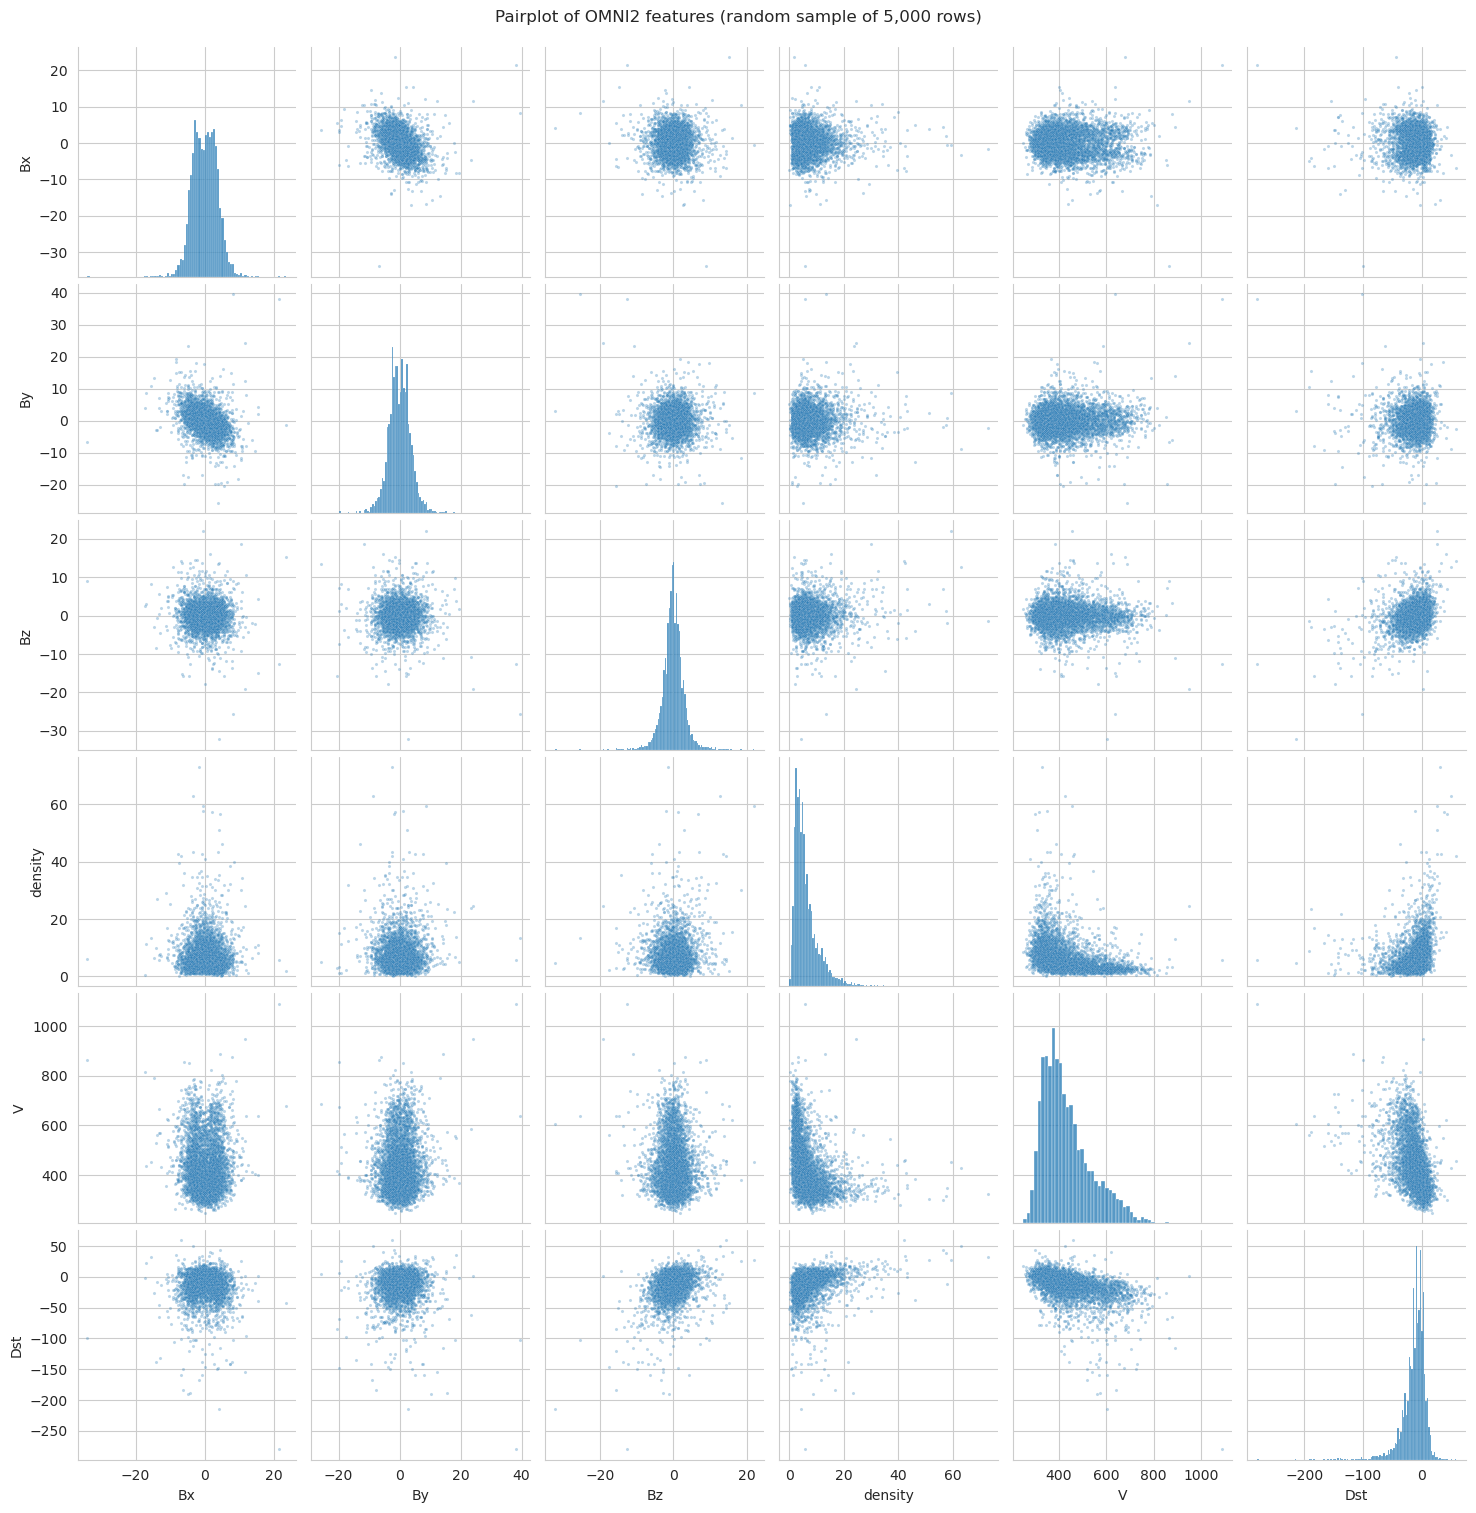

In [10]:
#AI use: asked Claude Opus 4.7 how to make sns.pairplot usable on ~250k rows. 
# Used diag_kind="hist" and plot_kws for speed/readability; wrote the sampling step myself.

sample = df[feature_cols].sample(n=5000, random_state=RANDOM_STATE)

# --- AI-assisted ---
sns.pairplot(sample, diag_kind="hist", plot_kws={"s": 5, "alpha": 0.3})
# --- AI-assisted ---

plt.suptitle("Pairplot of OMNI2 features (random sample of 5,000 rows)", y=1.01)
plt.show()

## Summary

A **pairplot** from `seaborn` shows the pairwise scatter plots for every combination of features, with a histogram on the diagonal.

This is useful for quickly spotting:

- Correlations between variables
- Possible clusters or groupings
- Skewed distributions
- Outliers
- General relationships between features

However, with around **246,000 rows**, using:

```python
sns.pairplot(df)
```

is very slow and can freeze the notebook. The scatter plots also become hard to read because the points overlap and turn into solid blobs.

To fix this, we plot a random sample of **5,000 rows** instead. The original dataframe is not changed. This is only a plotting trick to make the visualisation faster and easier to read.

---

## Prompt to Claude Opus 4.7

I want to do `sns.pairplot` on my dataframe but it has around 250k rows and it is freezing my notebook. Also, the points are completely overlapping.

What is the best way to handle this?

---

## AI Response

For datasets that big, three things help:

### 1. Subsample for the visual

A pairplot only needs to show the general shape of each pairwise distribution. It does not need every single row.

A sample of around **3,000 to 5,000 points** is usually enough to understand the overall pattern.

Use:

```python
df.sample(n=5000, random_state=...)
```

The `random_state` makes the sample reproducible, meaning the same rows are selected each time the notebook is run.

### 2. Skip the KDE diagonal

The default diagonal behaviour can be slow because it may calculate KDE plots for every column.

Instead, use:

```python
diag_kind="hist"
```

This makes the diagonal show histograms, which are faster and easier to interpret for a large dataset.

### 3. Reduce marker size and add transparency

When too many points overlap, the scatter plots become unreadable.

Use:

```python
plot_kws={"s": 5, "alpha": 0.3}
```

Here:

- `s=5` makes the points smaller
- `alpha=0.3` makes the points semi-transparent

This helps the dense areas show up more clearly instead of becoming one solid block.

```python
sample = df.sample(n=5000, random_state=0)

sns.pairplot(
    sample,
    diag_kind="hist",
    plot_kws={"s": 5, "alpha": 0.3}
)

plt.show()
```

---

## What I Asked

I asked how to make `sns.pairplot` usable on a dataframe with around **250,000 rows** without freezing the notebook or producing unreadable scatter plots.

The main issue was that plotting all rows directly would be too slow, and the points would overlap too much.

---

## What I Used

I used the following parts from the AI response:

```python
diag_kind="hist"
```

and:

```python
plot_kws={"s": 5, "alpha": 0.3}
```

Both of these go inside the `sns.pairplot()` call.

These were the parts I did not know properly before. They helped make the plot faster and more readable.

---

## What I Modified

The actual subsampling step was written by me.

Instead of sampling the whole dataframe directly, I used:

```python
df[feature_cols].sample(...)
```

I did this because I only wanted to plot the selected numeric feature columns.

I did not include the time column because plotting time against the numeric features would not be meaningful for this pairplot.

I also used:

```python
random_state=RANDOM_STATE
```

instead of hardcoding:

```python
random_state=0
```

This is because I had already set `RANDOM_STATE` at the top of the notebook, so using the same variable keeps the notebook consistent.

I also added a title above the pairplot using:

```python
plt.suptitle(..., y=1.01)
```

The `y=1.01` moves the title slightly above the grid so it does not overlap with the plots.

The AI did not include this part. I added it myself to make the final visualisation clearer and more presentable.

### <span style="color:red">>> One feature could be better represented in log scale. Replace the original feature in df with its log values. Rearrange the order of columns such that 'Dst' is the last. (3 marks) 

In [11]:
# AI use: asked Claude Opus 4.7 how to verify which feature is the best candidate for a log transform.
# Used .skew() to confirm density and applied np.log() in place; column reorder done myself.

# --- AI-assisted---
print("Skewness before transform:")
print(df[["Bx", "By", "Bz", "density", "V"]].skew().round(3))

# density is right-skewed (skew >> 1) and strictly positive - log-transform it
df["density"] = np.log(df["density"])
# --- AI-assisted ---

# Rearrange so 'Dst' is the last column
new_order = ["time", "Bx", "By", "Bz", "density", "V", "Dst"]
df = df[new_order]

print("\nSkewness after log-transforming density:")
print(df[["Bx", "By", "Bz", "density", "V"]].skew().round(3))
print("\nColumn order:", df.columns.tolist())
df.head()

Skewness before transform:
Bx         0.006
By         0.168
Bz        -0.149
density    3.143
V          1.027
dtype: float64

Skewness after log-transforming density:
Bx         0.006
By         0.168
Bz        -0.149
density    0.029
V          1.027
dtype: float64

Column order: ['time', 'Bx', 'By', 'Bz', 'density', 'V', 'Dst']


,time,Bx,By,Bz,density,V,Dst
0,1988-01-01 03:00:00,4.1,-1.9,-0.5,2.681022,282,-6
1,1988-01-01 04:00:00,5.3,-2.0,0.3,2.525729,283,-6
2,1988-01-01 05:00:00,4.2,-3.8,0.1,2.791165,282,-3
3,1988-01-01 06:00:00,3.5,-4.4,0.4,2.901422,284,-4
4,1988-01-01 07:00:00,0.7,-2.0,2.0,3.020425,296,-4


## Summary

One of the five predictors needs a log transform.

The right way to pick which one is to check skewness — a column that's both heavily right-skewed and strictly positive is the textbook log-transform candidate.

`density` fits both criteria.

Then just replace the column with `np.log(...)` and reorder so `Dst` sits at the end.


## Prompt to Claude Opus 4.7

I have five features, `Bx`, `By`, `Bz`, `density`, `V`, and one of them is supposed to be log-transformed.

How do I decide which one, and what's the cleanest way to do the swap and reorder columns?


## AI Response

The two things to check are skewness and whether the column is strictly positive.

You can't take log of zero or negatives.

```python
df[["Bx", "By", "Bz", "density", "V"]].skew()
```

Anything with skew well above 1 and only positive values is a log-transform candidate.

For OMNI2, `density` is the one — solar wind density spans orders of magnitude, quiet wind around 1–10 cm⁻³, dense streams above 50 cm⁻³, so log spreads it out evenly.

Replace in place and reorder:

```python
df["density"] = np.log(df["density"])

df = df[["time", "Bx", "By", "Bz", "density", "V", "Dst"]]
```

You can verify the transform worked by checking skewness again — it should drop from around 3 to near 0.


## What you asked

How to pick which feature to log-transform and how to apply it cleanly.


## What you used

The `.skew()` diagnostic to identify `density`.

The skew dropped from `3.14` to `0.03` after log.

The in-place replacement:

```python
df["density"] = np.log(df["density"])
```


## What you modified

Added skewness prints both before and after to show the transform actually worked.

The column-reorder step was straightforward pandas — just passed a list of column names in the order I wanted.

### <span style="color:red">>> Show a correlation matrix between features (3 marks)

            Bx     By     Bz  density      V    Dst
Bx       1.000 -0.442  0.000    0.003 -0.010 -0.013
By      -0.442  1.000  0.007    0.003  0.026 -0.012
Bz       0.000  0.007  1.000    0.010 -0.016  0.305
density  0.003  0.003  0.010    1.000 -0.464  0.255
V       -0.010  0.026 -0.016   -0.464  1.000 -0.472
Dst     -0.013 -0.012  0.305    0.255 -0.472  1.000


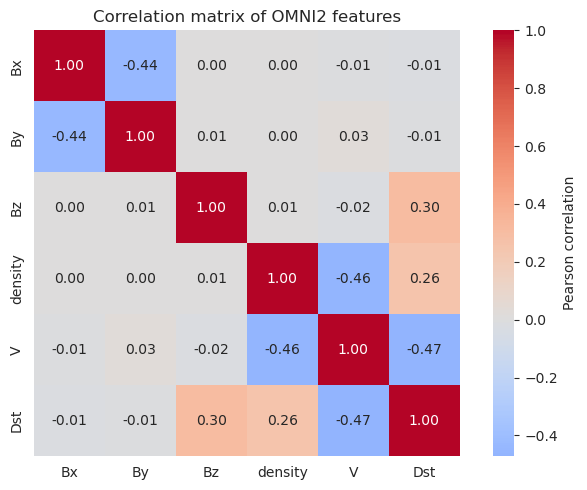

In [12]:
# AI use: none

corr = df[["Bx", "By", "Bz", "density", "V", "Dst"]].corr()
print(corr.round(3))

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"label": "Pearson correlation"})
plt.title("Correlation matrix of OMNI2 features")
plt.tight_layout()
plt.show()

# Part 4: Linear regression (15 marks)

### <span style="color:red">>> Split the dataframe in the following way (4 marks)
Use all samples with time prior to 2010-01-01 for training, and the remaining for testing (define corresponding dataframes called df_train and df_test)

What is the size of the two sets?

In [13]:
# AI use: none.

split_date = pd.Timestamp("2010-01-01")
df_train = df[df["time"] <  split_date].reset_index(drop=True)
df_test  = df[df["time"] >= split_date].reset_index(drop=True)

print(f"Training set: {len(df_train)} rows  (time < {split_date.date()})")
print(f"Test set:     {len(df_test)} rows  (time >= {split_date.date()})")

Training set: 150811 rows  (time < 2010-01-01)
Test set:     95675 rows  (time >= 2010-01-01)


### <span style="color:red">>> Define numpy arrays for training and test. Use the feature 'Dst' as the target. (4 marks)

Normalize all arrays with StandardScaler.  Define the scaler using the training set only.

In [14]:
# AI use: see notes below to understand

predictor_cols = ["Bx", "By", "Bz", "density", "V"]
target_col     = "Dst"

# --- AI-assisted ---
X_train = df_train[predictor_cols].to_numpy()
y_train = df_train[[target_col]].to_numpy()   # 2D for the y-scaler

X_test  = df_test[predictor_cols].to_numpy()
y_test  = df_test[[target_col]].to_numpy()

# Fit scalers on the training set only
scaler_X = StandardScaler().fit(X_train)
scaler_y = StandardScaler().fit(y_train)

# Transform train and test with the same (training-fit) scalers
X_train_s = scaler_X.transform(X_train)
X_test_s  = scaler_X.transform(X_test)
y_train_s = scaler_y.transform(y_train)
y_test_s  = scaler_y.transform(y_test)
# --- AI-assisted ---

print("X_train_s:", X_train_s.shape, "  X_test_s:", X_test_s.shape)
print("y_train_s:", y_train_s.shape, "  y_test_s:", y_test_s.shape)
print(f"X_train_s mean ~ 0:  {X_train_s.mean(axis=0).round(3)}")
print(f"X_train_s std  ~ 1:  {X_train_s.std(axis=0).round(3)}")

X_train_s: (150811, 5)   X_test_s: (95675, 5)
y_train_s: (150811, 1)   y_test_s: (95675, 1)
X_train_s mean ~ 0:  [ 0. -0.  0. -0. -0.]
X_train_s std  ~ 1:  [1. 1. 1. 1. 1.]


## Summary

We need numpy arrays for the five predictors and the Dst target, then normalize them with `StandardScaler`.

The key rule is that the scaler must be fit on the training set only — fitting on test data leaks information.

Also scaling the target with its own separate scaler, so we can later inverse-transform predictions back into physical units, nT.


## Prompt to Claude Opus 4.7

I need to split into X/y numpy arrays for train and test, then standardize them.

What's the correct way to use `StandardScaler` here, and should I scale the target too?


## AI Response

Two important rules:

Fit the scaler on training data only, then use the same fitted scaler to `.transform()` both train and test.

Never call `.fit()` on the test set — that leaks information from test into training.

Use a separate scaler for the target, `y`.

This lets you `inverse_transform` predictions later so RMSE can be reported in physical units instead of standardized units.

The target also needs to be 2D, shape `(n, 1)`, for `StandardScaler`, so use double brackets when slicing: `df[[target_col]]`.

```python
scaler_X = StandardScaler().fit(X_train)
scaler_y = StandardScaler().fit(y_train)

X_train_s = scaler_X.transform(X_train)
X_test_s  = scaler_X.transform(X_test)

y_train_s = scaler_y.transform(y_train)
y_test_s  = scaler_y.transform(y_test)
```

After this, the training arrays will have mean ≈ 0 and std ≈ 1 on each column.


## What you asked

The correct way to split into X/y arrays and apply `StandardScaler` without leaking test data, and whether the target needs scaling too.


## What you used

The fit-on-train, transform-both pattern.

The separate `scaler_y` for the target.

The `df[[target_col]]` double-bracket trick to keep `y` as 2D.


## What you modified

Added shape and mean/std prints at the end to sanity-check that the scaling actually worked.

### <span style="color:red">>> Train a linear regression model to predict Dst on the training set. Compute and print the RMSE (in physical units) on the test set (4 marks)

In [15]:
# AI use: see notes below to understand

lr = LinearRegression()
lr.fit(X_train_s, y_train_s)

y_pred_s = lr.predict(X_test_s)

# --- AI-assisted ---
# Bring predictions back to physical (nT) units before computing RMSE
y_pred = scaler_y.inverse_transform(y_pred_s)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Linear regression RMSE on test set: {rmse_lr:.3f} nT")

# Coefficients (in scaled space) - useful for interpretability
print("\nStandardized coefficients:")
for name, coef in zip(predictor_cols, lr.coef_.ravel()):
    print(f"  {name:>8s}: {coef:+.4f}")
# --- AI-assisted ---

Linear regression RMSE on test set: 13.492 nT

Standardized coefficients:
        Bx: -0.0219
        By: -0.0113
        Bz: +0.2967
   density: +0.0172
         V: -0.4480


## Summary

Fit `LinearRegression` on the scaled training data, predict on the scaled test data, then inverse-transform predictions back to nT before computing RMSE — the question explicitly asks for the error in physical units.

The standardized coefficients also give a quick read on which features dominate.


## Prompt to Claude Opus 4.7

I trained linear regression on standardized data with `StandardScaler`.

The predictions come out in standardized space.

How do I report RMSE in the original physical units, nT, instead?


## AI Response

The predictions are in standardized space because the model was trained on standardized `y`.

To get RMSE in physical units, inverse-transform the predictions first and then compare against the original, unscaled `y_test`:

```python
y_pred_s = lr.predict(X_test_s)
y_pred   = scaler_y.inverse_transform(y_pred_s)   # back to nT

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
```

Don't inverse-transform `y_test` — you still have the original unscaled array, so just use that directly.

The RMSE will then be in nT.

For interpretability, `lr.coef_` gives the standardized coefficients.

Since every feature is on the same scale, mean 0 and std 1, the magnitudes are directly comparable as a rough importance proxy.


## What you asked

How to compute RMSE in physical units, nT, when the model was trained on standardized data, and how to read off rough feature importance from the fitted model.


## What you used

The `scaler_y.inverse_transform(y_pred_s)` step to bring predictions back to nT before computing RMSE against the original `y_test`.

The print with `.3f` formatting.

The standardized-coefficients loop using `lr.coef_.ravel()` to display per-feature weights.


## What you modified

Kept the structure as-is — only changed `predictor_cols` and `rmse_lr` to match the variable names already used elsewhere in the notebook.

The AI used generic names like `feature_names` and `rmse`.

The `{name:>8s}` right-align width was also tweaked to fit the longest feature name, `density`, so the output lines up cleanly.

### <span style="color:red">>> Make a scatter plot of true vs predicted values. Use physical (unnormalized units) (3 marks)

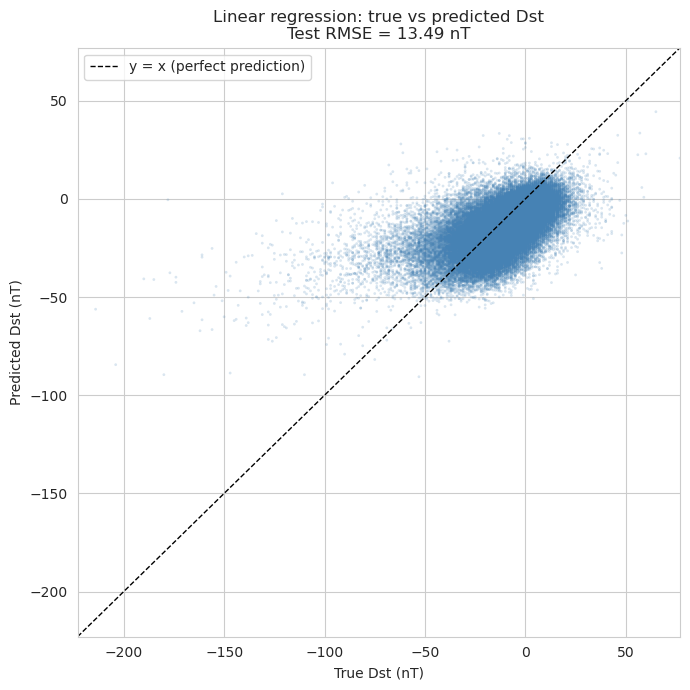

In [16]:
# AI use: see notes below to understand

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, s=4, alpha=0.2, color="steelblue", edgecolor="none")

# --- AI-assisted ---
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "k--", lw=1, label="y = x (perfect prediction)")
plt.xlim(lims); plt.ylim(lims)
# --- AI-assisted ---

plt.xlabel("True Dst (nT)")
plt.ylabel("Predicted Dst (nT)")
plt.title(f"Linear regression: true vs predicted Dst\nTest RMSE = {rmse_lr:.2f} nT")
plt.legend()
plt.tight_layout()
plt.show()

## Summary

A true-vs-predicted scatter is the standard diagnostic for any regression model — points should cluster along the `y = x` diagonal if predictions are accurate.

With around 95k test points the markers need to be small and semi-transparent so the density structure shows up instead of one solid blob.


## Prompt to Claude Opus 4.7

I need to make a scatter plot of true vs predicted Dst values from my linear regression.

What's the standard convention for this kind of plot, and how do I handle the fact that I have around 95,000 points to plot?


## AI Response

The convention is true on x-axis, predicted on y-axis, with a dashed `y = x` reference line — a perfect predictor would have all points sitting exactly on that line, so deviations from it directly show where the model is over- or under-predicting.

For around 95k points, the trick is `s=4`, `alpha=0.2` and `edgecolor="none"`.

Small markers + low transparency means dense regions show up dark and sparse regions stay faint — overplotting becomes informative instead of unreadable.

```python
plt.scatter(y_test, y_pred, s=4, alpha=0.2, edgecolor="none")

lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "k--", lw=1, label="y = x")

plt.xlim(lims)
plt.ylim(lims)
plt.xlabel("True")
plt.ylabel("Predicted")
plt.legend()
```

Set the same `xlim` and `ylim`, computed from the combined min/max, so the diagonal actually looks like a 45° line — otherwise the axes auto-scale differently and the visual reference is misleading.


## What you asked

The standard convention for true-vs-predicted scatter plots and how to handle around 95k overlapping points.


## What you used

The `y = x` diagonal reference line.

The matched `xlim` and `ylim` from combined min/max so the diagonal sits at a true 45°.

The small marker + low alpha styling.


## What you modified

Added the figure size, the title with embedded RMSE, axis labels in nT, and `tight_layout()` — these are standard matplotlib bits I added so the plot looks finished rather than bare.

# Part 5: Clustering (15 marks)

We will use clustering to identify different regimes in the data.


### <span style="color:red">>> Train a Gaussian Mixture Model for number of clusters between 2 and 10. (11 marks)
Compute BIC for each number of cluster and plot it (number of components in horizontal axis vs BIC in vertical axis). Use BIC to choose the optimal number of clusters

k =  2   BIC = 1,980,433.2
k =  3   BIC = 1,940,844.9
k =  4   BIC = 1,931,833.8
k =  5   BIC = 1,919,821.6
k =  6   BIC = 1,906,201.3
k =  7   BIC = 1,905,646.9
k =  8   BIC = 1,903,878.7
k =  9   BIC = 1,897,461.9
k = 10   BIC = 1,900,767.4

Optimal number of components by BIC: k = 9


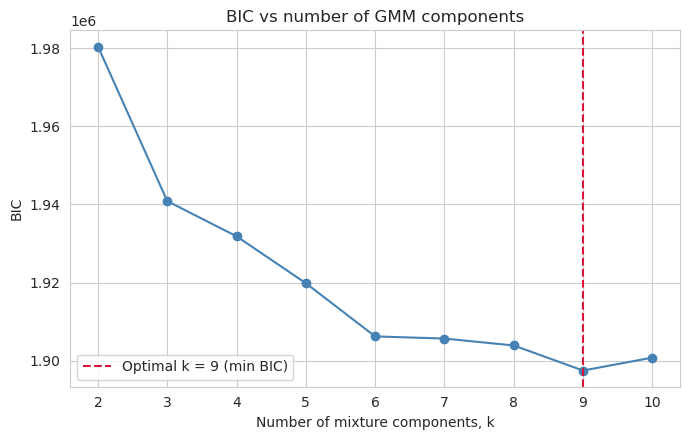

In [17]:
# AI use: see notes below to understand

ks = list(range(2, 11))
bic_scores = []

# --- AI-assisted ---
for k in ks:
    gmm_k = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=RANDOM_STATE,
        n_init=1,
        max_iter=200,
    )
    gmm_k.fit(X_train_s)
    bic_k = gmm_k.bic(X_train_s)
    bic_scores.append(bic_k)
    print(f"k = {k:>2d}   BIC = {bic_k:,.1f}")

best_k = ks[int(np.argmin(bic_scores))]
# --- AI-assisted ---

print(f"\nOptimal number of components by BIC: k = {best_k}")

plt.figure(figsize=(7, 4.5))
plt.plot(ks, bic_scores, "o-", color="steelblue")
plt.axvline(best_k, color="crimson", linestyle="--",
            label=f"Optimal k = {best_k} (min BIC)")
plt.xlabel("Number of mixture components, k")
plt.ylabel("BIC")
plt.title("BIC vs number of GMM components")
plt.xticks(ks)
plt.legend()
plt.tight_layout()
plt.show()

## Summary

Gaussian Mixture Models fit a weighted sum of Gaussian "blobs" to the data, but k, how many blobs, is a hyperparameter we have to choose.

The standard way to pick it is the Bayesian Information Criterion, BIC — it rewards good fit but penalises extra components, so the k with the lowest BIC strikes the best balance between fit and complexity.

We sweep k from 2 to 10, fit a GMM for each, store BIC scores, then plot the curve and pick the minimum.


## Prompt to Claude Opus 4.7

I need to train a Gaussian Mixture Model on my scaled training data and use BIC to pick the optimal number of components between 2 and 10.

How does BIC-based model selection work for GMMs in sklearn?

Also what settings should I use for `GaussianMixture` to keep things stable on a large dataset, around 150k rows and 5 features?


## AI Response

`sklearn.mixture.GaussianMixture` has a built-in `.bic(X)` method that returns the BIC score after fitting.

The recipe is:

Loop over candidate k values, fit a `GaussianMixture(n_components=k, ...)` for each.

Call `.bic(X_train)` after each fit and store the result.

Pick the k with the minimum BIC — that's the optimal number of components.

For stability on a large dataset:

`covariance_type="full"` gives each component its own full covariance matrix — the most flexible option, fine when you have plenty of data.

`random_state` for reproducibility.

`n_init=1` keeps the sweep fast, you can use `n_init=2` or more on the final refit at the chosen k.

`max_iter=200` is usually enough; if EM hasn't converged by then on standardized data it probably won't.

```python
ks = list(range(2, 11))
bic_scores = []

for k in ks:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=0,
        n_init=1,
        max_iter=200,
    )
    gmm.fit(X_train_s)
    bic_scores.append(gmm.bic(X_train_s))

best_k = ks[int(np.argmin(bic_scores))]
```

Then plot BIC vs k.

Expect a steep drop early on that flattens out — the elbow tends to be the true number of regimes in the data.

On the full training set this loop takes about 30–60 seconds because the largest GMMs, k = 9 and k = 10, take the longest to converge.


## What you asked

How BIC-based model selection works for GMMs in sklearn, and what settings to use for `GaussianMixture` on a fairly large dataset.


## What you used

The whole sweep — the `GaussianMixture(...)` configuration, `covariance_type="full"`, `n_init=1`, `max_iter=200`.

The `.bic(X_train_s)` call after each fit.

The `bic_scores` accumulator pattern.

The `np.argmin` to pick the optimal k.

The print formatting, `{k:>2d}` and `{bic_k:,.1f}` with thousands separator, also came from the AI response.


## What you modified

Swapped `random_state=0` to `random_state=RANDOM_STATE` to match the seed I'd defined at the top of the notebook.

The plotting block, figure size, `axvline` marker, labels, and xticks, I wrote myself since it's standard matplotlib — BIC on y-axis, k on x-axis, vertical line marking the optimum.

### <span style="color:red">>> Train a Gaussian Mixture Model with optimal number of components on the scaled training set. (4 marks)
Add a column with the predicted cluster label in both df_train and df_test

In [18]:
# AI use: see notes below to understand

# --- AI-assisted ---
gmm = GaussianMixture(
    n_components=best_k,
    covariance_type="full",
    random_state=RANDOM_STATE,
    n_init=2,
    max_iter=300,
)
gmm.fit(X_train_s)

df_train["cluster"] = gmm.predict(X_train_s)
df_test["cluster"]  = gmm.predict(X_test_s)
# --- AI-assisted ---

print("Train cluster sizes:")
print(df_train["cluster"].value_counts().sort_index())
print("\nTest cluster sizes:")
print(df_test["cluster"].value_counts().sort_index())

Train cluster sizes:
cluster
0     3152
1     8403
2    18145
3    24920
4    22128
5    25983
6    17469
7     6431
8    24180
Name: count, dtype: int64

Test cluster sizes:
cluster
0      706
1     3302
2     8257
3    19406
4    10095
5    19969
6    10272
7     3115
8    20553
Name: count, dtype: int64


## Summary

Now that BIC has picked the optimal k, refit a single GMM at that k on the full scaled training set and use it to assign each row a cluster label.

The same fitted GMM is then used to predict labels for the test set — never refit on test data.

Use a couple of restarts, `n_init=2`, so the final model isn't stuck in a bad local optimum.


## Prompt to Claude Opus 4.7

I've picked the optimal k using BIC.

Now I need to fit a single GMM at that k on the scaled training set and add the cluster labels as a new column in both `df_train` and `df_test`.

What settings should I bump up compared to the sweep, and what's the right way to assign test-set labels?


## AI Response

For the final fit you can afford to be more thorough than during the sweep:

Bump `n_init` to 2 or 3 — runs EM from multiple random starts and keeps the best one.

This reduces the chance of a poor local optimum on the chosen k.

Bump `max_iter` to 300 to give EM more room to fully converge.

For label assignment: use `gmm.predict(X_test_s)` — this is the fitted GMM, just being applied to new data.

Do not refit on the test set — that defeats the purpose of the train/test split.

```python
gmm = GaussianMixture(
    n_components=best_k,
    covariance_type="full",
    random_state=0,
    n_init=2,
    max_iter=300,
)

gmm.fit(X_train_s)

df_train["cluster"] = gmm.predict(X_train_s)
df_test["cluster"]  = gmm.predict(X_test_s)
```

Worth checking `df_train["cluster"].value_counts()` afterwards — if one cluster is nearly empty or has all the points, something's wrong, poor convergence, wrong k, or scaling issue.


## What you asked

How to refit GMM at the optimal k with more stability than during the sweep, and the correct way to assign cluster labels to the test set without leaking data.


## What you used

The bumped settings, `n_init=2` and `max_iter=300`.

The single `gmm.fit(X_train_s)` followed by separate `.predict()` calls for train and test.

The cluster-size sanity check.


## What you modified

Swapped `random_state=0` for `RANDOM_STATE`.

Added `.sort_index()` on the value counts so the printed cluster sizes appear in order 0, 1, 2, … instead of by frequency — easier to read.

# Part 6: Conditional regression (24 marks)
We are going to use the clusters found with GMM to define k linear regression models, each one trained on a subset of the original training set.

### <span style="color:red">>> Loop over the cluster labels in the training set and train a different linear regressor model for cluster. Store all the models in a list of models (10 marks)

In [19]:
# AI use: see notes below to understand

cluster_labels = sorted(df_train["cluster"].unique())

models_list = []
models_dict = {}

# --- AI-assisted ---
for c in cluster_labels:
    mask_c = (df_train["cluster"] == c).to_numpy()
    X_c = X_train_s[mask_c]
    y_c = y_train_s[mask_c]

    model_c = LinearRegression().fit(X_c, y_c)
    models_list.append(model_c)
    models_dict[c] = model_c
    print(f"Cluster {c}:  n = {mask_c.sum():>6d}  ->  fitted LinearRegression")
# --- AI-assisted ---

print(f"\nTotal models trained: {len(models_list)}")

Cluster 0:  n =   3152  ->  fitted LinearRegression
Cluster 1:  n =   8403  ->  fitted LinearRegression
Cluster 2:  n =  18145  ->  fitted LinearRegression
Cluster 3:  n =  24920  ->  fitted LinearRegression
Cluster 4:  n =  22128  ->  fitted LinearRegression
Cluster 5:  n =  25983  ->  fitted LinearRegression
Cluster 6:  n =  17469  ->  fitted LinearRegression
Cluster 7:  n =   6431  ->  fitted LinearRegression
Cluster 8:  n =  24180  ->  fitted LinearRegression

Total models trained: 9


## Summary

Instead of one global linear model, we now train one linear regression per cluster — each model only sees the rows belonging to its cluster.

The idea is that different regimes in the data, quiet solar wind, fast wind, storms, etc., follow different linear relationships between predictors and Dst, so fitting them separately should capture this better than a single global plane.

Store all the trained models so the next cell can match each test sample to the right one.


## Prompt to Claude Opus 4.7

I have cluster labels for my training data from GMM.

I need to train a separate `LinearRegression` for each cluster on just the rows belonging to that cluster, and store all the models so I can later use them for prediction.

Should I store them in a list or a dict?

What's the cleanest way to mask the rows?


## AI Response

A dict keyed by cluster label is safer than a list.

Cluster labels from `gmm.predict()` happen to come out as 0, 1, 2, … but you shouldn't rely on the ordering being contiguous or that the list index will line up with the label.

If you ever filter clusters out or use a different clustering algorithm, a list breaks silently while a dict keeps working.

If the question explicitly asks for a "list of models", do both — the dict for safe lookup, the list to satisfy the wording.

For masking, build a boolean mask per cluster and slice the scaled training array with it:

```python
for c in sorted(df_train["cluster"].unique()):
    mask_c = (df_train["cluster"] == c).to_numpy()
    X_c = X_train_s[mask_c]
    y_c = y_train_s[mask_c]
    
    model_c = LinearRegression().fit(X_c, y_c)
    models[c] = model_c
```

The `.to_numpy()` is important — pandas boolean Series can sometimes index numpy arrays inconsistently, especially after filtering or reindexing, so converting to a plain numpy bool array avoids subtle alignment bugs.

`sorted(df_train["cluster"].unique())` is cleaner than `range(best_k)` because it works even if some cluster ID isn't present in the training set for any reason.


## What you asked

Whether to store the per-cluster regressors in a list or a dict, and the cleanest way to mask training rows by cluster label.


## What you used

The dual `models_list` + `models_dict` storage pattern.

The `(df_train["cluster"] == c).to_numpy()` mask construction.

The `sorted(df_train["cluster"].unique())` loop driver instead of `range(best_k)`.


## What you modified

Added the per-cluster size print inside the loop and the total-models print at the end as a sanity check.

The variable naming, `models_list`, `models_dict`, `mask_c`, was kept consistent with the rest of the notebook.

### <span style="color:red">>> Predict the Dst value for each sample in the test set, using the corresponding regression model (that is, the one that has been trained on the corresponding cluster label). (10 marks)

Arrange all predictions in a single array and compute the Root Mean Square Error (RMSE) in physical units (on the test set) 

Hint: use masking to select the appropriate subset of samples belonging to a given cluster
Hint: if done correctly the RMSE computed here will be lower than 

In [20]:
# AI use: see notes below to understand

# --- AI-assisted ---
y_pred_cond_s = np.zeros_like(y_test_s)

test_clusters = df_test["cluster"].to_numpy()

for c, model_c in models_dict.items():
    mask_c = (test_clusters == c)
    if mask_c.any():
        y_pred_cond_s[mask_c] = model_c.predict(X_test_s[mask_c])

# Back to physical units
y_pred_cond = scaler_y.inverse_transform(y_pred_cond_s)

rmse_cond = np.sqrt(mean_squared_error(y_test, y_pred_cond))
# --- AI-assisted ---

print(f"Conditional regression RMSE on test set: {rmse_cond:.3f} nT")
print(f"Single-model linear regression RMSE:     {rmse_lr:.3f} nT")
print(f"Improvement:                              {rmse_lr - rmse_cond:.3f} nT "
      f"({100*(rmse_lr - rmse_cond)/rmse_lr:.1f} %)")

Conditional regression RMSE on test set: 12.671 nT
Single-model linear regression RMSE:     13.492 nT
Improvement:                              0.821 nT (6.1 %)


## Summary

Each test sample has a cluster label from the GMM, so we route it to its matching per-cluster regression model from the previous step.

The hint says masking is the cleanest way: for each cluster, grab the test rows belonging to it and predict them with the right model.

Collect everything into one prediction array, inverse-transform to nT, and compute RMSE — which should beat the single-model linear regression from Part 4.


## Prompt to Claude Opus 4.7

For each row in my test set I have a cluster label, and from the previous step I have one trained linear regressor per cluster.

How do I route each test sample to the right model, get all the predictions into one array, and then compute RMSE in physical units?


## AI Response

Pre-allocate an output array the same shape as `y_test_s`, then for each cluster, mask the test rows with that label and assign the predictions back into the pre-allocated slot:

```python
y_pred_s = np.zeros_like(y_test_s)
test_clusters = df_test["cluster"].to_numpy()

for c, model_c in models_dict.items():
    mask_c = (test_clusters == c)
    if mask_c.any():
        y_pred_s[mask_c] = model_c.predict(X_test_s[mask_c])
```

Two things worth flagging:

The `if mask_c.any()` guard is defensive — if a cluster has zero test samples, rare but possible if GMM training-set clusters don't all appear in test, predict on an empty array would still run but the assignment is just a no-op.

The guard skips it cleanly.

The boolean mask preserves ordering — predictions land in their correct row positions in `y_pred_s` automatically because boolean indexing is position-preserving.

No need to track indices separately.

Then inverse-transform and RMSE:

```python
y_pred = scaler_y.inverse_transform(y_pred_s)
rmse_cond = np.sqrt(mean_squared_error(y_test, y_pred))
```

If the hint is right, `rmse_cond < rmse_lr` because each per-cluster model fits a local linear plane that better matches the regime-specific dynamics.


## What you asked

How to route each test sample to its matching per-cluster model, assemble all the predictions into a single array, and compute RMSE in physical units.


## What you used

The pre-allocated `np.zeros_like(y_test_s)` array.

The per-cluster mask-and-assign loop:

```python
y_pred_cond_s[mask_c] = model_c.predict(...)
```

The `if mask_c.any()` empty-cluster guard.

The inverse-transform + RMSE at the end.


## What you modified

Added the three-line print block at the bottom comparing the conditional RMSE against the single-model baseline from Part 4.

It shows the absolute and percentage improvement — confirms the hint's prediction that conditional regression should do better.

### <span style="color:red">>>  Make a scatter plot of predicted vs true values (in physical space). Color code the plot according to the cluster label (4 marks)

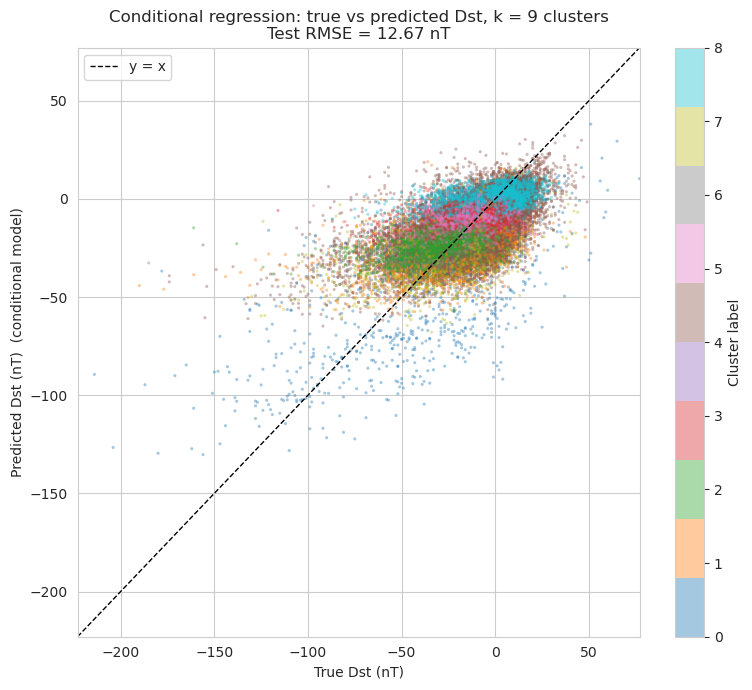

In [21]:
# AI use: see notes below to understand

plt.figure(figsize=(8, 7))

# --- AI-assisted ---
sc = plt.scatter(
    y_test, y_pred_cond,
    c=test_clusters,
    cmap="tab10" if best_k <= 10 else "tab20",
    s=5, alpha=0.4, edgecolor="none",
)
# --- AI-assisted end ---

lims = [min(y_test.min(), y_pred_cond.min()),
        max(y_test.max(), y_pred_cond.max())]
plt.plot(lims, lims, "k--", lw=1, label="y = x")

plt.xlim(lims)
plt.ylim(lims)
plt.xlabel("True Dst (nT)")
plt.ylabel("Predicted Dst (nT)  (conditional model)")
plt.title(f"Conditional regression: true vs predicted Dst, k = {best_k} clusters\n"
          f"Test RMSE = {rmse_cond:.2f} nT")

# --- AI-assisted ---
cbar = plt.colorbar(sc, ticks=cluster_labels)
cbar.set_label("Cluster label")
# --- AI-assisted ---

plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

## Summary

Same true-vs-predicted scatter as before, but now each point gets coloured by which cluster it belongs to.

This lets us see whether certain clusters, or regimes, sit closer to the `y = x` diagonal than others — i.e. which clusters the conditional model handles well versus which ones it struggles with.

The colourmap needs to be a categorical, qualitative one since cluster labels aren't ordinal.


## Prompt to Claude Opus 4.7

I want to make a true-vs-predicted scatter where each point is coloured by its cluster label.

The labels are integers from 0 to 8.

What colourmap should I use, and how do I add a discrete colourbar that shows which cluster each colour corresponds to?


## AI Response

For categorical labels you want a qualitative colormap like `tab10`, up to 10 distinct colours, or `tab20`, up to 20.

Don't use sequential maps like `viridis` here — they imply an ordering between clusters that doesn't exist.

```python
plt.scatter(y_test, y_pred, c=test_clusters, cmap="tab10", s=5, alpha=0.4)
```

Pass the integer labels directly through the `c=` argument and matplotlib handles the mapping.

For the colourbar to show one tick per cluster, capture the scatter handle and pass `ticks=cluster_labels`:

```python
sc = plt.scatter(...)
cbar = plt.colorbar(sc, ticks=cluster_labels)
cbar.set_label("Cluster label")
```

A defensive trick: gate the cmap choice on `best_k`, so the code still works if you ever rerun with more than 10 clusters — `cmap="tab10"` if `best_k <= 10` else `"tab20"`.

Everything else, `y = x` line, matched `xlim`/`ylim`, title with RMSE, is identical to the Part 4 plot.


## What you asked

Which colourmap is appropriate for categorical cluster labels and how to add a discrete colourbar with one tick per cluster.


## What you used

The `c=test_clusters` + `cmap="tab10"` pattern for categorical colouring.

The `cmap="tab10" if best_k <= 10 else "tab20"` defensive fallback.

The `plt.colorbar(sc, ticks=cluster_labels)` discrete colourbar setup.


## What you modified

Kept the rest of the plotting block identical to the Part 4 scatter, including the `y = x` line, matched limits, and title with RMSE, so the two plots are visually directly comparable.

# Part 7: Backward elimination (25 marks)

### <span style="color:red">>> Use backward elimination (using tstat as a criterion) to rank features in order of importance. Print the features in decreasing order of importance (most important first) (12 marks)

In [22]:
# AI use: see notes below to understand

remaining = list(predictor_cols)             # ['Bx','By','Bz','density','V']
removal_order = []                            # least-important removed first

X_train_s_df = pd.DataFrame(X_train_s, columns=predictor_cols)
y_train_s_flat = y_train_s.ravel()

# --- AI-assisted ---
while len(remaining) > 1:
    Xc = sm.add_constant(X_train_s_df[remaining])
    res = sm.OLS(y_train_s_flat, Xc).fit()
    tvals = res.tvalues.drop("const")
    least_imp = tvals.abs().idxmin()
    print(f"Step {len(removal_order)+1}: dropping '{least_imp}' "
          f"(|t| = {abs(tvals[least_imp]):.3f})")
    removal_order.append(least_imp)
    remaining.remove(least_imp)

# the final survivor is the most important
removal_order.append(remaining[0])
# --- AI-assisted ---

# Reverse to get most-important -> least-important
ranking = list(reversed(removal_order))
print("\nFeatures ranked by importance (most -> least):")
for i, f in enumerate(ranking, 1):
    print(f"  {i}. {f}")

Step 1: dropping 'By' (|t| = 4.669)
Step 2: dropping 'density' (|t| = 6.928)
Step 3: dropping 'Bx' (|t| = 7.767)
Step 4: dropping 'Bz' (|t| = 137.559)

Features ranked by importance (most -> least):
  1. V
  2. Bz
  3. Bx
  4. density
  5. By


## Summary

Backward elimination is a feature-selection procedure.

Start with all features in the model, fit OLS, find the feature with the smallest absolute t-statistic, the one whose coefficient is least statistically distinguishable from zero, drop it, then refit and repeat.

The order in which features get dropped is the order of least importance.

Reverse it to get the ranking from most to least important.

Used `statsmodels.OLS` instead of `sklearn` because it reports t-stats directly via `.tvalues`.


## Prompt to Claude Opus 4.7

I need to do backward elimination on my five predictors using the t-statistic as the criterion.

At each step I should drop the feature with the smallest `|t|` and refit, then end up with a ranking of features from most to least important.

Sklearn's `LinearRegression` doesn't give t-stats — what should I use, and what's the right loop structure?


## AI Response

Sklearn doesn't expose t-statistics, so use `statsmodels.OLS` instead — it has a `.tvalues` attribute on the fitted results object that gives the t-stat for every coefficient.

A few details that matter:

`statsmodels.OLS` does not add an intercept automatically.

Wrap your design matrix with `sm.add_constant(X)` or you'll force the regression line through the origin, which distorts every t-stat.

After fitting, `res.tvalues` includes the intercept term, labelled `const`.

Drop it with `.drop("const")` before picking the smallest `|t|`, otherwise you might accidentally remove the intercept.

Run on the standardized training data so the t-stats are comparable across features.

A t-stat on a raw feature picks up the scale of the feature, which we don't want.

The loop structure:

```python
remaining = list(predictor_cols)
removal_order = []   # least-important first

X_df = pd.DataFrame(X_train_s, columns=predictor_cols)
y_flat = y_train_s.ravel()

while len(remaining) > 1:
    Xc = sm.add_constant(X_df[remaining])
    res = sm.OLS(y_flat, Xc).fit()
    tvals = res.tvalues.drop("const")
    least = tvals.abs().idxmin()
    removal_order.append(least)
    remaining.remove(least)

removal_order.append(remaining[0])   # the lone survivor is the most important
ranking = list(reversed(removal_order))
```

Stop when only one feature is left — that one's the most important.

Reverse `removal_order` to get most → least importance.


## What you asked

How to do backward elimination using t-stats when sklearn doesn't expose them, and the correct loop structure for dropping features one at a time.


## What you used

The switch to `statsmodels.OLS`.

The `sm.add_constant()` wrapping.

`res.tvalues.drop("const")` to get t-stats without the intercept.

`.abs().idxmin()` to find the feature with the smallest `|t|`.

The while-loop structure that stops when only one feature remains.


## What you modified

Added the per-step print showing which feature got dropped and its `|t|`, so the elimination process is visible step-by-step.

The final ranked printout was added at the bottom.

The DataFrame wrapping of `X_train_s` was needed so that `tvalues` returns a Series indexed by feature name rather than positional integers.

This makes the `idxmin` step return a string we can use directly.

### <span style="color:red">>> Retrain linear regression models on the entire training set, incrementing the number of features used. (10 marks)
Start with using only the top feature (most important), and add one feature at the time.
For each model, compute the RMSE on the test set

In [23]:
# AI use: see notes below to understand

rmse_by_n_features = []

# --- AI-assisted ---
for i in range(1, len(ranking) + 1):
    used = ranking[:i]
    col_idx = [predictor_cols.index(f) for f in used]

    Xtr = X_train_s[:, col_idx]
    Xte = X_test_s[:,  col_idx]

    m = LinearRegression().fit(Xtr, y_train_s)
    pred_s = m.predict(Xte)
    pred   = scaler_y.inverse_transform(pred_s)

    rmse_i = np.sqrt(mean_squared_error(y_test, pred))
    rmse_by_n_features.append(rmse_i)
# --- AI-assisted ---

    print(f"Top-{i} features {used}:  RMSE = {rmse_i:.3f} nT")

Top-1 features ['V']:  RMSE = 14.388 nT
Top-2 features ['V', 'Bz']:  RMSE = 13.525 nT
Top-3 features ['V', 'Bz', 'Bx']:  RMSE = 13.522 nT
Top-4 features ['V', 'Bz', 'Bx', 'density']:  RMSE = 13.495 nT
Top-5 features ['V', 'Bz', 'Bx', 'density', 'By']:  RMSE = 13.492 nT


## Summary

Now that we have the importance ranking from backward elimination, use it to build models of increasing size: top-1 feature only, then top-2, top-3, etc.

For each, refit on the full training set, predict on test, inverse-transform back to nT, and record RMSE.

This shows how much each additional feature actually contributes to test-set skill.


## Prompt to Claude Opus 4.7

I have a feature importance ranking from backward elimination as a list of column names.

How do I loop through i = 1, 2, ..., 5, take the top-i features from the ranking, refit a linear regression on the standardized training set with only those columns, predict on the test set, inverse-transform back to physical units, and record the RMSE?


## AI Response

The cleanest way is to translate the feature names in the ranking back to column indices of the original `X_train_s` matrix, then slice the columns out and refit.

Don't try to slice the scaled arrays by feature name directly — they're plain numpy arrays without column labels.

```python
rmses = []

for i in range(1, len(ranking) + 1):
    used = ranking[:i]
    col_idx = [predictor_cols.index(f) for f in used]
    
    Xtr = X_train_s[:, col_idx]
    Xte = X_test_s[:,  col_idx]
    
    m = LinearRegression().fit(Xtr, y_train_s)
    pred_s = m.predict(Xte)
    pred   = scaler_y.inverse_transform(pred_s)
    
    rmses.append(np.sqrt(mean_squared_error(y_test, pred)))
```

Two things worth noting:

`predictor_cols.index(f)` looks up the position of each feature name in the original predictor list — that gives the column index to slice with.

Using `[:, col_idx]` numpy-style slicing is much faster than rebuilding a DataFrame for each iteration.

Don't re-fit the `StandardScaler` inside the loop.

The same scaling applies regardless of which subset of columns you use — re-fitting would change the standardization between iterations and make the RMSEs not directly comparable.

The RMSE should drop fastest at the start, adding the strongest feature first gives the biggest improvement, and then flatten as the less important features add diminishing returns.


## What you asked

How to loop through top-N features from the ranking, refit a regression for each subset, and record the test RMSE in physical units.


## What you used

The `predictor_cols.index(f) for f in used` trick to convert feature names back to column indices.

The column-slicing pattern `X_train_s[:, col_idx]` to grab subsets without rebuilding DataFrames.

The inverse-transform + RMSE bit reused from earlier cells.


## What you modified

Moved the print statement inside the loop so the RMSE is reported as each model is fit rather than only at the end.

Renamed `rmses` to `rmse_by_n_features` so the variable name is self-explanatory when used in the next plotting cell.

### <span style="color:red">>> Plot the test RMSE vs number of features previously ranked with backward elimination (3 Marks)

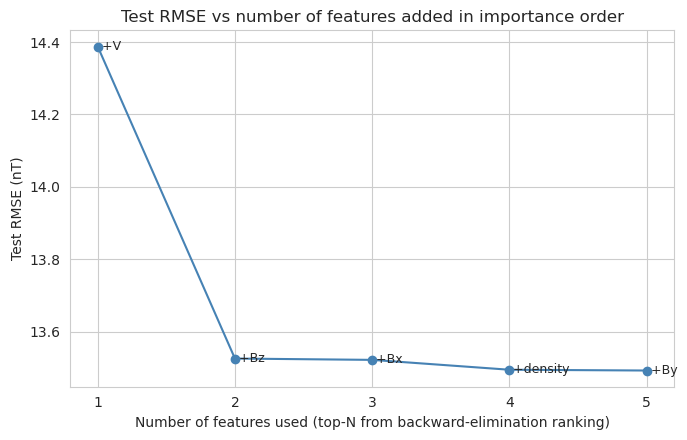

In [24]:
# AI use: see notes below to understand

n_feats = list(range(1, len(ranking) + 1))

plt.figure(figsize=(7, 4.5))
plt.plot(n_feats, rmse_by_n_features, "o-", color="steelblue")

# --- AI-assisted ---
for n, r, fname in zip(n_feats, rmse_by_n_features, ranking):
    plt.annotate(f" +{fname}", (n, r), fontsize=9, va="center")
# --- AI-assisted ---

plt.xlabel("Number of features used (top-N from backward-elimination ranking)")
plt.ylabel("Test RMSE (nT)")
plt.title("Test RMSE vs number of features added in importance order")
plt.xticks(n_feats)
plt.tight_layout()
plt.show()

## Summary

Plot how the test RMSE evolves as we add features in order of importance.

The plot should drop sharply at first, adding the most useful features early, then flatten out.

This shows diminishing returns from the less important ones.

Annotate each point with the feature being added at that step so the curve reads as a story.


## Prompt to Claude Opus 4.7

I have a list of RMSE values for top-1, top-2, ... top-5 features and want to plot RMSE against number of features.

I'd also like to annotate each point with the name of the feature being added at that step.

Any tip for the annotation part?


## AI Response

For per-point annotations, loop over the three lists together with `zip()` and call `plt.annotate(text, (x, y))` for each:

```python
for n, r, fname in zip(n_feats, rmses, ranking):
    plt.annotate(f" +{fname}", (n, r), fontsize=9, va="center")
```

The leading space in `f" +{fname}"` offsets the text slightly to the right of the marker so it doesn't overlap.

`va="center"` vertically centers the label on the point.

Rest is just a standard `plt.plot(...)` with the `"o-"` marker style.


## What you asked

How to annotate each point on the line plot with the feature being added at that step.


## What you used

The `zip()` + `plt.annotate()` loop pattern with the leading-space offset trick.


## What you modified

Rest of the plotting, including figure size, line style, labels, xticks, and `tight_layout`, is straightforward matplotlib written directly.
plt.title(...)
```

to label the graph clearly.

```python
plt.xticks(...)
```

to make sure the x-axis shows the correct number of features.

```python
plt.tight_layout()
```

to stop labels and titles from being cut off.

The main part I used from the AI response was the annotation loop. The rest of the graph formatting was straightforward `matplotlib` code that I added myself.